In [12]:
import yfinance as yf
import pandas as pd

ticker = "GOOG"
start_date = "2023-01-01"
end_date = "2023-12-31"

df = yf.download(ticker, start=start_date, end=end_date, progress=False)


if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

# Ensure datetime index
df.index = pd.to_datetime(df.index)
df = df.sort_index()


C:\Users\weldi\AppData\Local\Temp\ipykernel_14536\2620002738.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start_date, end=end_date, progress=False)


In [13]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
import talib as ta


In [15]:
df['Daily_Return'] = df['Close'].pct_change()
df['Cumulative_Return'] = (1 + df['Daily_Return']).cumprod() - 1


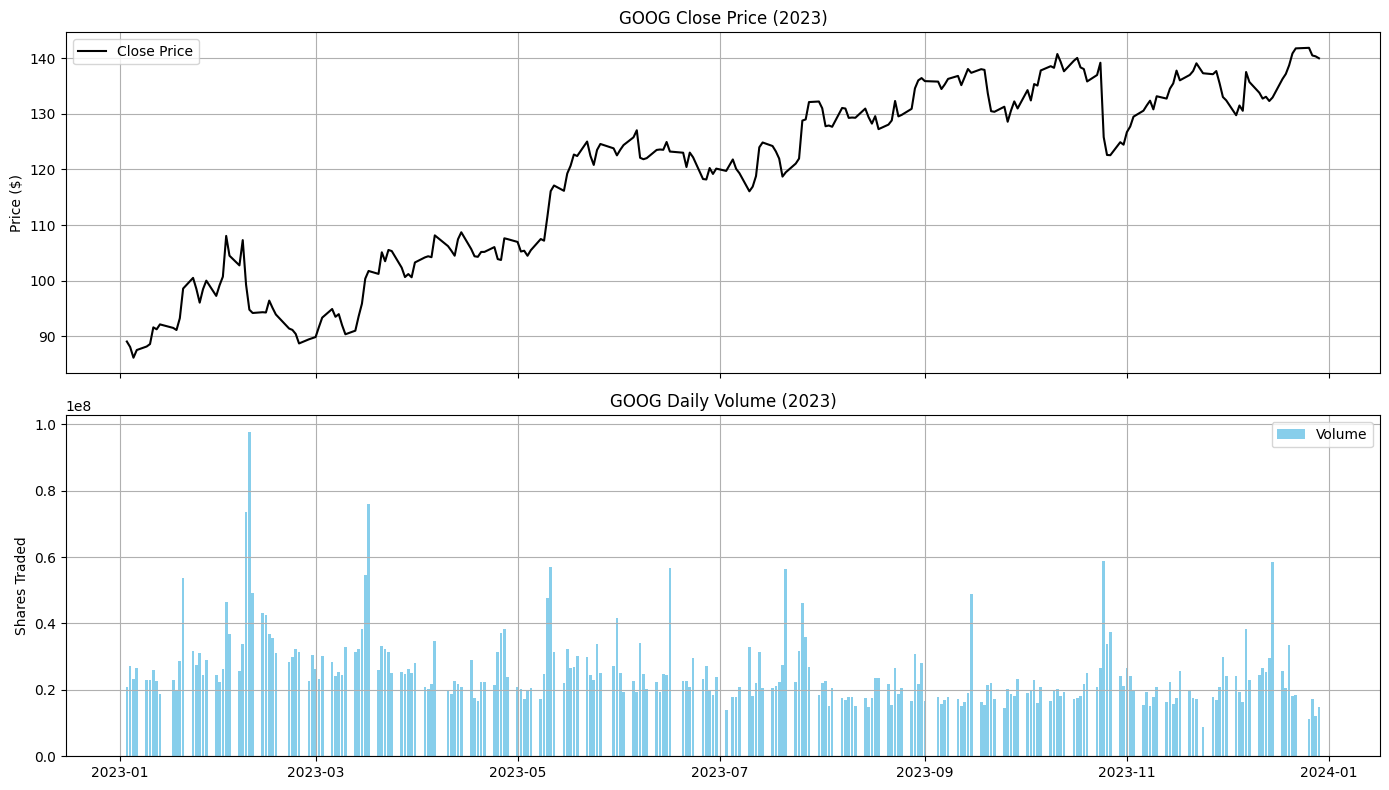

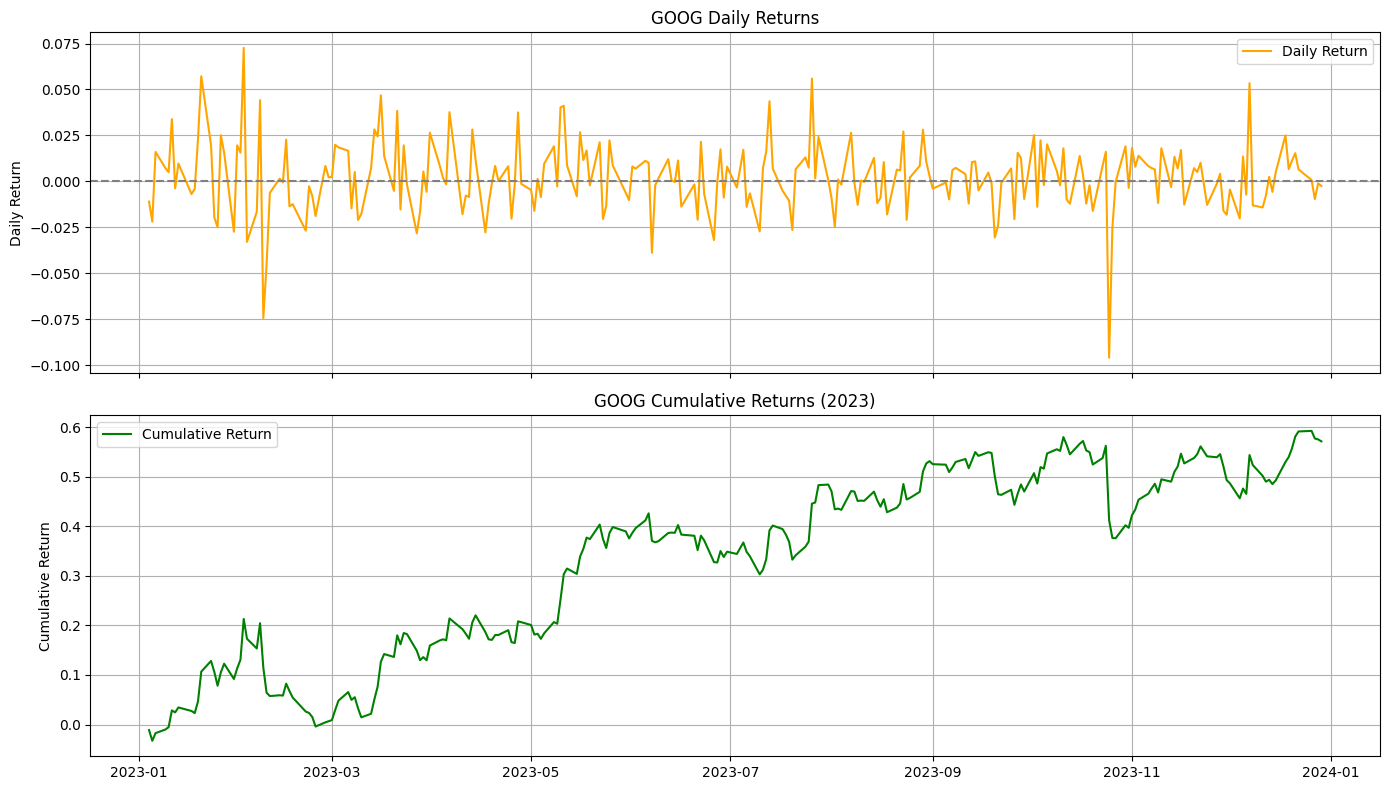

Descriptive statistics for Close, Daily Return, and Cumulative Return:
                   count        mean        std        min         25%  \
Price                                                                    
Close              250.0  118.798889  16.261983  86.180252  104.427879   
Daily_Return       249.0    0.002002   0.019283  -0.095989   -0.009166   
Cumulative_Return  249.0    0.334805   0.181666  -0.032664    0.172910   

                          50%         75%         max  
Price                                                  
Close              123.122444  132.384064  141.849289  
Daily_Return         0.001476    0.012045    0.072661  
Cumulative_Return    0.383055    0.486065    0.592196  


In [16]:

# Price, Volume, Daily Returns & Cumulative Returns

import matplotlib.pyplot as plt

# --- Price & Volume ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Close price
ax1.plot(df.index, df['Close'], color='black', label='Close Price')
ax1.set_ylabel('Price ($)')
ax1.set_title('GOOG Close Price (2023)')
ax1.legend()
ax1.grid(True)

# Volume
ax2.bar(df.index, df['Volume'], color='skyblue', label='Volume')
ax2.set_ylabel('Shares Traded')
ax2.set_title('GOOG Daily Volume (2023)')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()


# --- Daily Returns & Cumulative Returns ---
fig, (ax3, ax4) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Daily Returns
ax3.plot(df.index, df['Daily_Return'], color='orange', label='Daily Return')
ax3.set_ylabel('Daily Return')
ax3.set_title('GOOG Daily Returns')
ax3.axhline(0, color='gray', linestyle='--')
ax3.legend()
ax3.grid(True)

# Cumulative Returns
ax4.plot(df.index, df['Cumulative_Return'], color='green', label='Cumulative Return')
ax4.set_ylabel('Cumulative Return')
ax4.set_title('GOOG Cumulative Returns (2023)')
ax4.legend()
ax4.grid(True)

plt.tight_layout()
plt.show()


# Descriptive stats
print("Descriptive statistics for Close, Daily Return, and Cumulative Return:")
print(df[['Close','Daily_Return','Cumulative_Return']].describe().T)


In [17]:
import talib


df['SMA_20'] = talib.SMA(df['Close'], timeperiod=20)
df['SMA_50'] = talib.SMA(df['Close'], timeperiod=50)


df['RSI'] = talib.RSI(df['Close'], timeperiod=14)


df['MACD'], df['MACD_signal'], df['MACD_hist'] = talib.MACD(df['Close'], fastperiod=12, slowperiod=26, signalperiod=9)

print(df.tail())


Price            Close        High         Low        Open    Volume  \
Date                                                                   
2023-12-22  141.749954  142.276351  141.089466  141.163968  18513500   
2023-12-26  141.849289  142.966643  141.531457  142.008190  11170100   
2023-12-27  140.478683  142.345911  140.092320  141.859236  17288400   
2023-12-28  140.319763  141.303040  139.870839  140.885896  12192500   
2023-12-29  139.972153  140.473725  138.949154  139.723852  14881000   

Price       Daily_Return  Cumulative_Return      SMA_20      SMA_50  \
Date                                                                  
2023-12-22      0.006488           0.591081  135.009592  133.914786   
2023-12-26      0.000701           0.592196  135.246472  133.999009   
2023-12-27     -0.009662           0.576812  135.386514  134.017880   
2023-12-28     -0.001131           0.575028  135.628856  134.023641   
2023-12-29     -0.002477           0.571126  135.976975  134.056417  

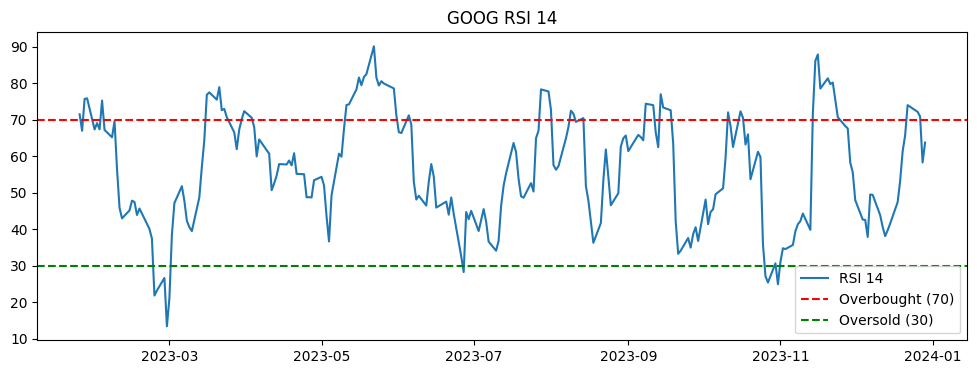

In [18]:
import pandas as pd
import matplotlib.pyplot as plt


df['Close'] = df['Close']


delta = df['Close'].diff()

# Separate gains and losses
gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)

# Calculate rolling averages
avg_gain = gain.rolling(window=14, min_periods=14).mean()
avg_loss = loss.rolling(window=14, min_periods=14).mean()

# Compute RSI
rs = avg_gain / avg_loss
df['RSI_14'] = 100 - (100 / (1 + rs))

# Plot RSI
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df.index, df['RSI_14'], label='RSI 14')
ax.axhline(70, color='red', linestyle='--', label='Overbought (70)')
ax.axhline(30, color='green', linestyle='--', label='Oversold (30)')
ax.set_title('GOOG RSI 14')
ax.legend()
plt.show()


In [20]:
import pandas as pd


df['Daily_Return'] = df['Close'].pct_change() * 100  
df[['Close', 'Daily_Return']].head()



Price,Close,Daily_Return
Date,,
2023-01-03,89.090324,NaN
2023-01-04,88.107056,-1.103676
2023-01-05,86.180252,-2.186889
2023-01-06,87.560799,1.601929
2023-01-09,88.196449,0.725953


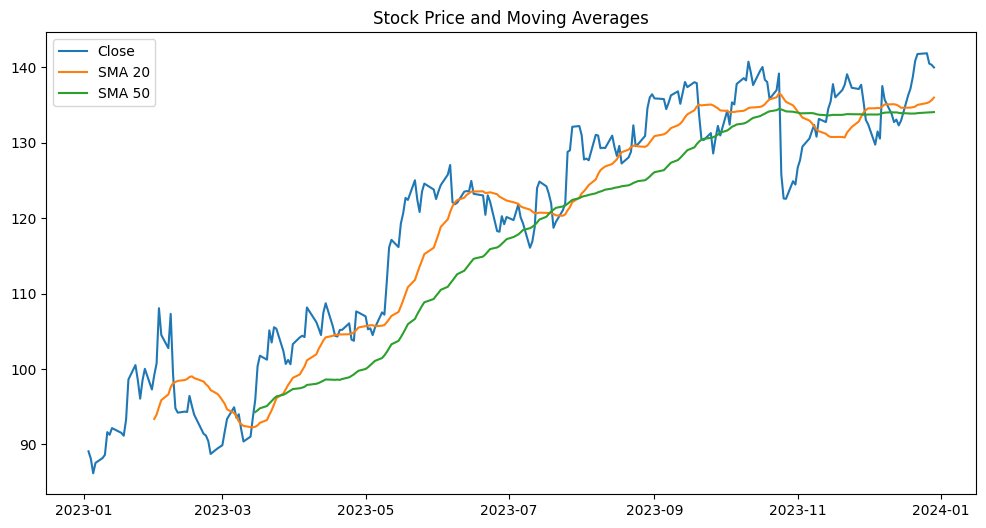

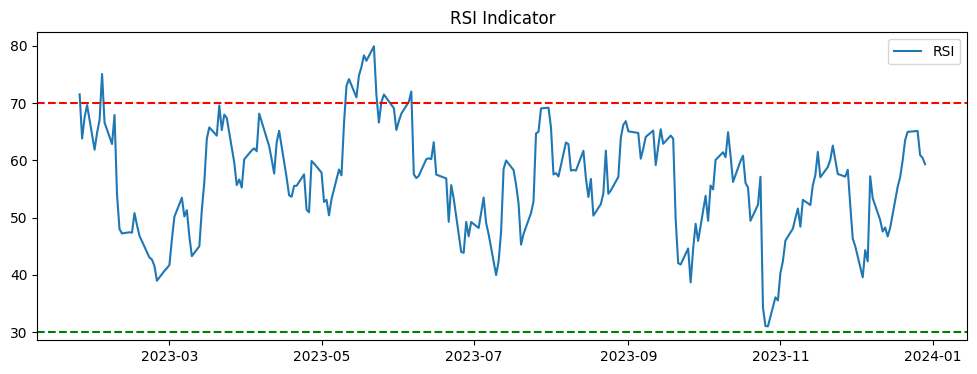

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(df['Close'], label='Close')
plt.plot(df['SMA_20'], label='SMA 20')
plt.plot(df['SMA_50'], label='SMA 50')
plt.title('Stock Price and Moving Averages')
plt.legend()
plt.show()

plt.figure(figsize=(12,4))
plt.plot(df['RSI'], label='RSI')
plt.axhline(70, color='red', linestyle='--')
plt.axhline(30, color='green', linestyle='--')
plt.title('RSI Indicator')
plt.legend()
plt.show()


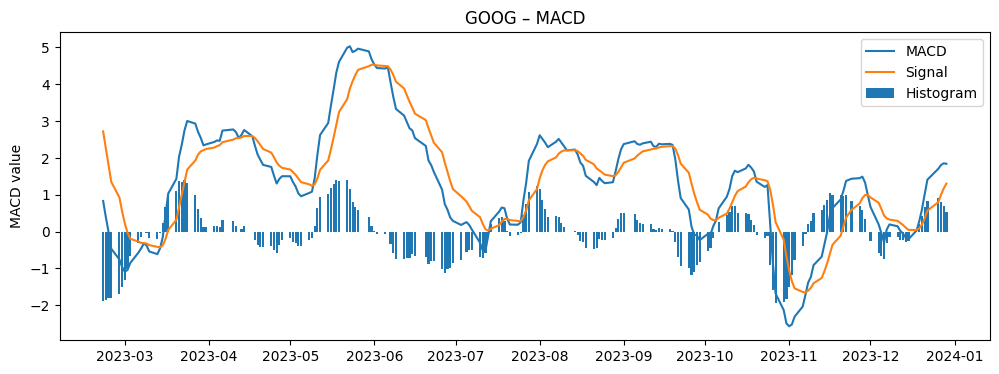

In [22]:

# MACD – Trend & momentum

fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(df.index, df["MACD"], label="MACD")
ax.plot(df.index, df["MACD_signal"], label="Signal")
ax.bar(df.index, df["MACD_hist"], label="Histogram")

ax.set_title("GOOG – MACD")
ax.set_ylabel("MACD value")
ax.legend()
plt.show()


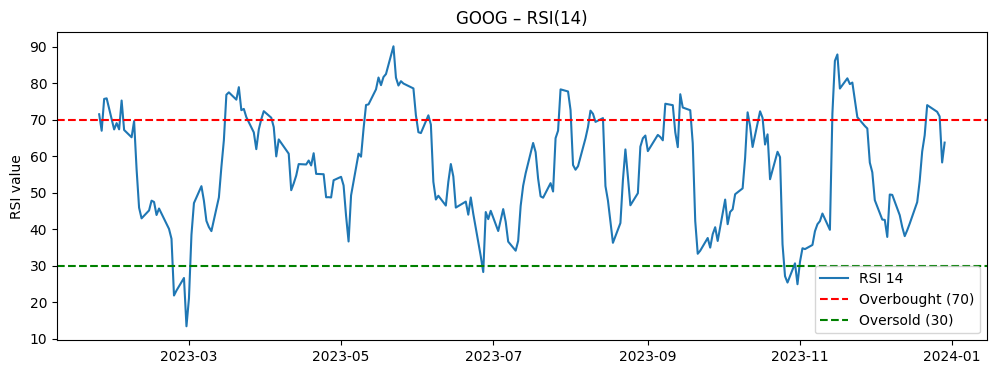

In [ ]:

# RSI – Overbought / Oversold


fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(df.index, df["RSI_14"], label="RSI 14")
ax.axhline(70, color="red", linestyle="--", label="Overbought (70)")
ax.axhline(30, color="green", linestyle="--", label="Oversold (30)")

ax.set_title("GOOG – RSI(14)")
ax.set_ylabel("RSI value")
ax.legend()
plt.show()


In [ ]:
# Step 5: PyNance Portfolio Metrics
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

from pynance import portfolio_optimizer as po

# Select tickers for your portfolio
ticker_list = ['TSLA', 'AAPL', 'MSFT']

# Create a PortfolioCalculations object
portfolio = po.PortfolioCalculations(ticker_list)

# Max Sharpe Portfolio
max_sharpe_rr = portfolio.max_sharpe_portfolio('rr')
max_sharpe_df = portfolio.max_sharpe_portfolio('df')
print("Max Sharpe Portfolio Risk/Return:")
print(max_sharpe_rr)
print("\nPortfolio Weights:")
print(max_sharpe_df)

# Min Variance Portfolio
min_var_rr = portfolio.min_var_portfolio('rr')
min_var_df = portfolio.min_var_portfolio('df')
print("\nMin Variance Portfolio Risk/Return:")
print(min_var_rr)
print("\nPortfolio Weights (Min Variance):")
print(min_var_df)

# Efficient Frontier Plot
fig = portfolio.efficient_frontier()
fig.show()
